In [ ]:
pip install statsbombpy mplsoccer matplotlib pandas

In [1]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch

# See all free competitions available
competitions = sb.competitions()
print(competitions[['competition_name', 'season_name', 'competition_id', 'season_id']].to_string())

           competition_name season_name  competition_id  season_id
0             1. Bundesliga   2023/2024               9        281
1             1. Bundesliga   2015/2016               9         27
2    African Cup of Nations        2023            1267        107
3          Champions League   2018/2019              16          4
4          Champions League   2017/2018              16          1
5          Champions League   2016/2017              16          2
6          Champions League   2015/2016              16         27
7          Champions League   2014/2015              16         26
8          Champions League   2013/2014              16         25
9          Champions League   2012/2013              16         24
10         Champions League   2011/2012              16         23
11         Champions League   2010/2011              16         22
12         Champions League   2009/2010              16         21
13         Champions League   2008/2009              16       

In [2]:
# Load all matches from Euro 2024
matches = sb.matches(competition_id=55, season_id=282)
print(f"Total matches: {len(matches)}")
print(matches[['match_id', 'home_team', 'away_team', 'home_score', 'away_score']].head(10))

Total matches: 51
   match_id home_team       away_team  home_score  away_score
0   3930166  Portugal  Czech Republic           2           1
1   3930159   Hungary     Switzerland           1           3
2   3930163    Serbia         England           0           1
3   3930181   England        Slovenia           0           0
4   3930178   Croatia           Italy           1           1
5   3930160     Spain         Croatia           3           0
6   3930170  Slovenia          Serbia           1           1
7   3938643    France          Poland           1           1
8   3938641    Poland         Austria           1           3
9   3938642   Georgia  Czech Republic           1           1


In [4]:
# Load all events from Euro 2024 (this takes ~1-2 minutes)
all_events = []
for match_id in matches['match_id']:
    events = sb.events(match_id=match_id)
    all_events.append(events)

df = pd.concat(all_events, ignore_index=True)
print(f"Total events loaded: {len(df):,}")
print(df['type'].value_counts().head(10))  # See what event types exist

Total events loaded: 187,924
type
Pass             53888
Ball Receipt*    51608
Carry            44157
Pressure         14534
Ball Recovery     4144
Duel              3069
Block             2002
Clearance         1834
Goal Keeper       1622
Shot              1340
Name: count, dtype: int64


In [5]:
# Filter only shot events
shots = df[df['type'] == 'Shot'].copy()

# Extract x, y coordinates from the location column
shots[['x', 'y']] = pd.DataFrame(shots['location'].tolist(), index=shots.index)

# Extract xG (expected goals) — StatsBomb includes this in shot data
shots['xg'] = shots['shot_statsbomb_xg']

# Extract shot outcome
shots['outcome'] = shots['shot_outcome'].apply(lambda x: x if isinstance(x, str) else 'Unknown')

print(f"Total shots: {len(shots)}")
print(shots[['player', 'team', 'x', 'y', 'xg', 'outcome']].head())

Total shots: 1340
                                   player            team      x     y  \
3404                           Pavel Šulc  Czech Republic  103.0  33.9   
3405  Cristiano Ronaldo dos Santos Aveiro        Portugal  108.6  40.1   
3406                          Nuno Mendes        Portugal   89.6  25.3   
3407         Rúben Santos Gato Alves Dias        Portugal   99.7  52.2   
3408            João Pedro Cavaco Cancelo        Portugal  104.7  25.1   

            xg  outcome  
3404  0.060549  Blocked  
3405  0.054355    Off T  
3406  0.007153    Off T  
3407  0.031687  Blocked  
3408  0.028343  Blocked  


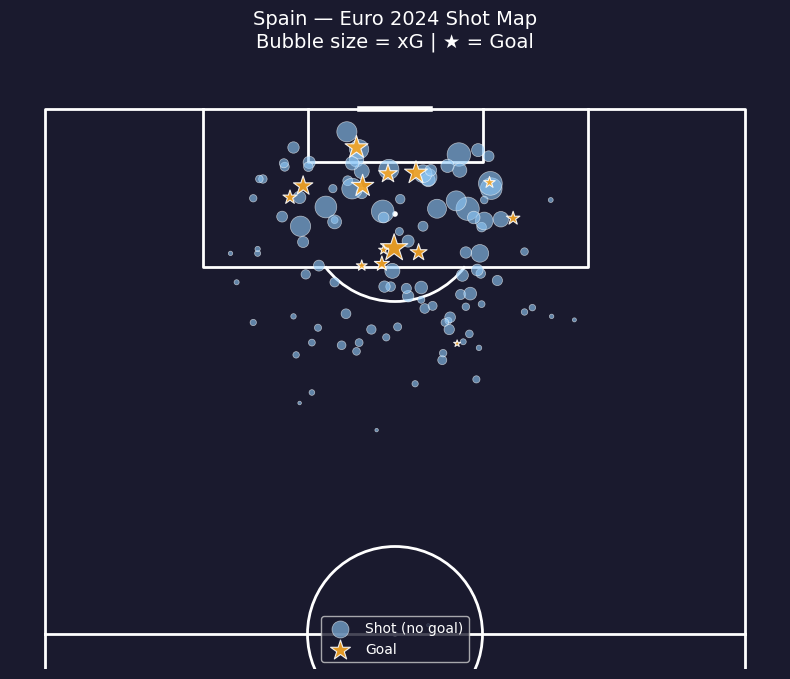

In [10]:
# Filter for Spain's shots
team = "Spain"
spain_shots = shots[shots['team'] == team].copy()

goals = spain_shots[spain_shots['outcome'] == 'Goal']
non_goals = spain_shots[spain_shots['outcome'] != 'Goal']

# Set up the pitch
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='white',
                      half=True)
fig, ax = pitch.draw(figsize=(8, 10))
fig.set_facecolor('#1a1a2e')

# Plot non-goal shots (size = xG value)
pitch.scatter(non_goals.x, non_goals.y,
              s=non_goals.xg * 1000,      # bubble size = xG
              c='#90caf9', alpha=0.6,
              edgecolors='white', linewidth=0.5,
              ax=ax, label='Shot (no goal)')

# Plot goals in a different colour
pitch.scatter(goals.x, goals.y,
              s=goals.xg * 1000,
              c='#f9a825', alpha=0.9,
              edgecolors='white', linewidth=0.8,
              ax=ax, marker='*', label='Goal')

ax.set_title(f"{team} — Euro 2024 Shot Map\nBubble size = xG | ★ = Goal",
             color='white', fontsize=14, pad=20)
ax.legend(loc='lower center', facecolor='#1a1a2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\varun\Desktop\euro2024_outputs\spain_shot_map.png", dpi=150, bbox_inches='tight')
plt.show()

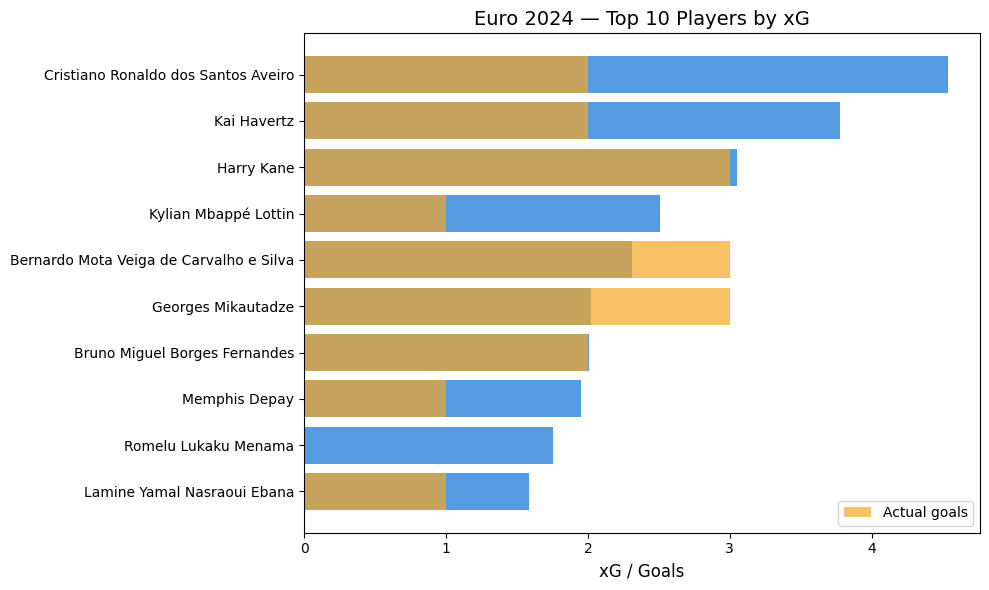

                                      player         team  shots_taken  total_xg  goals  xg_diff
56       Cristiano Ronaldo dos Santos Aveiro     Portugal           25      4.54      2    -2.54
155                              Kai Havertz      Germany           19      3.78      2    -1.78
109                               Harry Kane      England           18      3.05      3    -0.05
172                     Kylian Mbappé Lottin       France           24      2.51      1    -1.51
39   Bernardo Mota Veiga de Carvalho e Silva     Portugal            9      2.31      3     0.69
96                        Georges Mikautadze      Georgia            6      2.03      3     0.97
43             Bruno Miguel Borges Fernandes     Portugal           11      2.01      2    -0.01
208                            Memphis Depay  Netherlands           18      1.95      1    -0.95
278                     Romelu Lukaku Menama      Belgium           11      1.75      0    -1.75
174              Lamine Yamal 

In [11]:
# Group by player, sum xG and count goals
player_stats = shots.groupby('player').agg(
    total_xg=('xg', 'sum'),
    shots_taken=('xg', 'count'),
    goals=('outcome', lambda x: (x == 'Goal').sum()),
    team=('team', 'first')
).reset_index()

# xG difference: positive = overperformer, negative = underperformer
player_stats['xg_diff'] = player_stats['goals'] - player_stats['total_xg']

# Top 10 by xG
top10 = player_stats.nlargest(10, 'total_xg')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['player'], top10['total_xg'], color='#378ADD', alpha=0.85)
ax.barh(top10['player'], top10['goals'], color='#f9a825', alpha=0.7, label='Actual goals')

ax.set_xlabel('xG / Goals', fontsize=12)
ax.set_title('Euro 2024 — Top 10 Players by xG', fontsize=14)
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(r"C:\Users\varun\Desktop\euro2024_outputs\euro2024_xg_leaderboard.png", dpi=150, bbox_inches='tight')
plt.show()

print(top10[['player', 'team', 'shots_taken', 'total_xg', 'goals', 'xg_diff']].round(2).to_string())

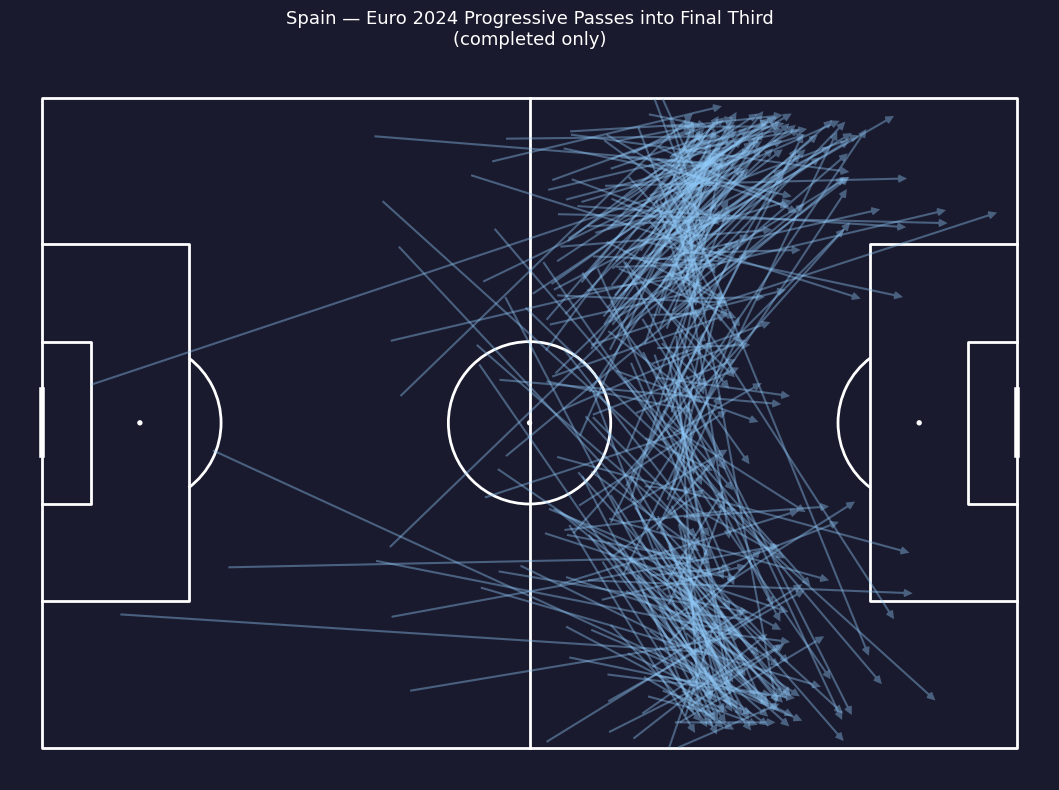

In [12]:
# Filter passes for a specific team
team = "Spain"
passes = df[(df['type'] == 'Pass') & (df['team'] == team)].copy()

# Extract coordinates
passes[['x', 'y']] = pd.DataFrame(passes['location'].tolist(), index=passes.index)
passes[['pass_end_x', 'pass_end_y']] = pd.DataFrame(
    passes['pass_end_location'].tolist(), index=passes.index)

# Progressive passes: started outside final third, ended inside final third
# StatsBomb pitch: x runs 0–120, final third starts at x=80
progressive = passes[
    (passes['x'] < 80) &
    (passes['pass_end_x'] >= 80) &
    (passes['pass_outcome'].isna())   # completed passes only
]

pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1a1a2e')

pitch.arrows(progressive.x, progressive.y,
             progressive.pass_end_x, progressive.pass_end_y,
             ax=ax, color='#90caf9', alpha=0.4, width=1.5,
             headwidth=4, headlength=4)

ax.set_title(f"{team} — Euro 2024 Progressive Passes into Final Third\n(completed only)",
             color='white', fontsize=13, pad=15)

plt.tight_layout()
plt.savefig(r"C:\Users\varun\Desktop\euro2024_outputs\spain_progressive_passes.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import os

# Create an outputs folder on your Desktop
output_dir = r"C:\Users\varun\Desktop\euro2024_outputs"
os.makedirs(output_dir, exist_ok=True)
print(f"Saving to: {output_dir}")

Saving to: C:\Users\varun\Desktop\euro2024_outputs
